In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


In [40]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

season_titles = {'winter':'Winter','spring':'Spring','summer':'Summer','autumn':'Autumn'}


In [42]:
'''
load result files
'''

result_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/'

# Detrending NAT (assigning to ANT)
tasmax_dfs = {}

# no processing results
df = pd.read_csv('/nesi/project/niwa00015/queenle/results/ECHAM5_PM_results_final.csv')
df = df.query('variable==\''+'tasmax'+'\' and trunc==\''+str(36)+'\' and time_step==\''+'annual'+'\'')

tasmax_dfs['No processing NAT trends'] = df
tasmax_dfs['NAT trend removed'] = pd.read_csv(result_dir + '/' + 'tasmax_annual_trunc_36.csv')
tasmax_dfs['NAT trend assigned to ANT'] = pd.read_csv(result_dir + '/detrend_nat_trend_all/' + 'tasmax_annual_trunc_36.csv')


# Detrending NAT and ALL (removing trend)

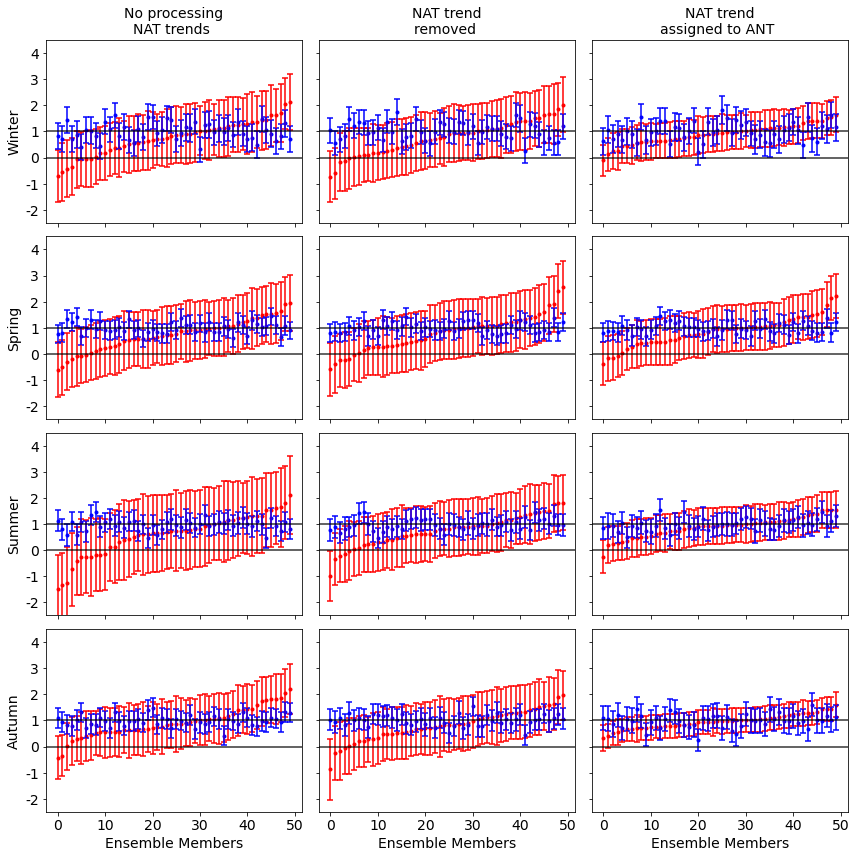

In [59]:
fig,axs = plt.subplots(4,3,figsize=(12,12),sharex=True,sharey=True)

for i,season in enumerate(['winter','spring','summer','autumn']):
    
    for j,scen in enumerate(tasmax_dfs.keys()):
        
        df = tasmax_dfs[scen].query('season==\''+season+'\'').sort_values('ant_best')

        ax = axs[i][j]

        x_vals = [i for i in range(len(df['ensemble_member']))]

        ax.scatter(x_vals,df['ant_best'],color='red',marker='.',label='ANT')
        ax.scatter(x_vals,df['ant_upper'],color='red',marker='_')
        ax.scatter(x_vals,df['ant_lower'],color='red',marker='_')
        ax.vlines(x_vals,df['ant_lower'],df['ant_upper'],color='red')

        ax.scatter(x_vals,df['nat_best'],color='blue',marker='.',label='NAT')
        ax.scatter(x_vals,df['nat_upper'],color='blue',marker='_')
        ax.scatter(x_vals,df['nat_lower'],color='blue',marker='_')
        ax.vlines(x_vals,df['nat_lower'],df['nat_upper'],color='blue')

        ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
        ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
        ax.set_ylim(-2.5,4.5)
        
        font['size']=20
        words = scen.split(' ')
        title = words[0] + ' ' + words[1] + '\n'
        for w in words[2:]:
            title+= w + ' '

        font['size']=14
        if i == 0:
            ax.set_title(title,fontdict=font)
            
        if i == 3:
            ax.set_xticks([0,10,20,30,40,50])
            ax.set_xticklabels(['0','10','20','30','40','50'],fontdict=font)
            ax.set_xlabel('Ensemble Members',fontdict=font)
            
        if j == 0:
            ax.set_yticks([-2,-1,0,1,2,3,4])
            ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
            ax.set_ylabel(season_titles[season],fontdict=font)
        font['size']=20
        
plt.tight_layout(pad=1)
fig.patch.set_alpha(1)

fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/ECHAM5_nat_trend_test_results.png',dpi=300)


In [45]:
scen.split(' ')[:2]+'\n'+scen.split(' ')[2:]

TypeError: can only concatenate list (not "str") to list

In [48]:
'{0} {1}\n{2} {3}'.format(scen.split(' '))

IndexError: tuple index out of range

In [49]:
scen.split(' ')[0]+' '+scen.split(' ')[1]+'\n'+scen.split(' ')

['No', 'processing', 'NAT', 'trends']

'No processing\nNAT trends'